# DDM Synthesis: Bootstrap CI Analysis

This notebook demonstrates the **comprehensive results synthesis** for three hypothesis tests on dependency distance minimization (DDM):

1. **Standardization Ranking Divergence** — Does sentence-length standardization change treebank DDM rankings? (Spearman ρ, Cohen's d)
2. **Cox PH Model** — Is case marking a stronger predictor of dependency distance than word order?
3. **Linking Mechanism** — Do case-rich languages have longer sentences and larger rank shifts?

Results include 95% bootstrap confidence intervals from resampled data.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# lifelines — NOT pre-installed on Colab
_pip('lifelines==0.29.0')

# Core packages — pre-installed on Colab, install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'scikit-learn==1.6.1')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lifelines 0.29.0 requires numpy<2.0,>=1.14.0, but you have numpy 2.0.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import math
import os

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## Data Loading

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/experiment_iter2_ddm_synthesis/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} treebank examples")
print(f"Pre-computed results available: {list(data['metadata']['results']['summary'].keys())}")

Loaded 25 treebank examples
Pre-computed results available: ['criterion_1_standardization', 'criterion_2_cox_case_vs_wo', 'criterion_3_linking_mechanism', 'overall_confirmed']


## Configuration

In [5]:
# Tunable parameters
N_BOOTSTRAP = 100  # Original: 1000
RNG = np.random.RandomState(42)

## Parse Examples into DataFrame

Each example has JSON-encoded `input` (treebank features, naive/standardized DDM) and `output` (ranks, rank shift).

In [6]:
rows = []
for ex in examples:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    rows.append({**inp, **out})

df_tb = pd.DataFrame(rows)
print(f"Parsed {len(df_tb)} treebanks")
df_tb.head()

Parsed 25 treebanks


,treebank_id,iso_code,word_order,case_richness,naive_ddm,standardized_ddm,naive_rank,standardized_rank,rank_shift
0,hy_armtdp,hy,No dominant order,5,0.4373,0.3908,126,71,55
1,hu_szeged,hu,No dominant order,8,0.5084,0.3916,71,69,2
2,de_lit,de,No dominant order,4,0.4375,0.3433,125,137,-12
3,el_lesbian,el,No dominant order,3,0.2721,0.1795,244,232,11
4,de_pud,de,No dominant order,3,0.4534,0.2805,109,186,-77


## Analysis 1: Standardization Ranking Divergence

Tests whether sentence-length standardization significantly changes treebank DDM rankings using Spearman ρ and Cohen's d with bootstrap CIs.

In [7]:
def analysis_standardization(df):
    """Test if standardization changes treebank rankings (rho < 0.85, Cohen's d > 0.5)."""
    df = df.dropna(subset=["naive_ddm", "standardized_ddm"]).copy()
    naive_ranks = df["naive_ddm"].rank(ascending=False)
    std_ranks = df["standardized_ddm"].rank(ascending=False)
    rank_shifts = naive_ranks - std_ranks

    rho, p_rho = stats.spearmanr(df["naive_ddm"], df["standardized_ddm"])
    cohens_d = abs(rank_shifts.mean()) / rank_shifts.std() if rank_shifts.std() > 0 else 0.0
    mean_abs_shift = rank_shifts.abs().mean()

    print(f"Spearman rho={rho:.4f} (p={p_rho:.2e}), Cohen's d={cohens_d:.4f}, mean|shift|={mean_abs_shift:.1f}")

    # Bootstrap
    rho_boots, d_boots = [], []
    n = len(df)
    for _ in range(N_BOOTSTRAP):
        idx = RNG.choice(n, size=n, replace=True)
        s = df.iloc[idx]
        r, _ = stats.spearmanr(s["naive_ddm"], s["standardized_ddm"])
        nr = s["naive_ddm"].rank(ascending=False)
        sr = s["standardized_ddm"].rank(ascending=False)
        rs = nr.values - sr.values
        d = abs(rs.mean()) / rs.std() if rs.std() > 0 else 0.0
        rho_boots.append(r)
        d_boots.append(d)

    rho_ci = [float(np.percentile(rho_boots, 2.5)), float(np.percentile(rho_boots, 97.5))]
    d_ci = [float(np.percentile(d_boots, 2.5)), float(np.percentile(d_boots, 97.5))]

    print(f"Bootstrap CIs: rho={rho_ci}, d={d_ci}")

    return {
        "rho": float(rho), "p_rho": float(p_rho), "rho_ci": rho_ci,
        "cohens_d": float(cohens_d), "d_ci": d_ci,
        "mean_abs_shift": float(mean_abs_shift),
        "pass_rho": bool(rho < 0.85), "pass_d": bool(cohens_d > 0.5),
        "n": int(n),
    }

results_std = analysis_standardization(df_tb)

Spearman rho=0.5777 (p=2.49e-03), Cohen's d=0.0000, mean|shift|=4.4
Bootstrap CIs: rho=[0.16876264449267184, 0.8909392176387675], d=[0.0, 0.0]


## Analysis 2: Linking Mechanism

Tests whether case-rich languages show larger rank shifts after standardization, mediated by sentence length.

In [8]:
def analysis_linking(df):
    """Test linking: case_richness → rank_shift correlation with bootstrap CIs."""
    df = df.dropna(subset=["naive_ddm", "standardized_ddm"]).copy()
    df["rank_shift_abs"] = (df["naive_ddm"].rank(ascending=False) - df["standardized_ddm"].rank(ascending=False)).abs()

    # Use per-treebank data (demo has no iso_code grouping needed — each row is unique)
    corr_cr, p_cr = stats.spearmanr(df["case_richness"], df["rank_shift_abs"])
    print(f"case_richness ~ |rank_shift|: r={corr_cr:.3f} (p={p_cr:.2e})")

    # Bootstrap
    boot_cr = []
    n = len(df)
    for _ in range(N_BOOTSTRAP):
        idx = RNG.choice(n, size=n, replace=True)
        s = df.iloc[idx]
        r, _ = stats.spearmanr(s["case_richness"], s["rank_shift_abs"])
        boot_cr.append(r)

    ci = [float(np.percentile(boot_cr, 2.5)), float(np.percentile(boot_cr, 97.5))]
    print(f"Bootstrap CI: {ci}")

    return {"corr": float(corr_cr), "p": float(p_cr), "ci_95": ci}

results_linking = analysis_linking(df_tb)

case_richness ~ |rank_shift|: r=-0.196 (p=3.49e-01)


Bootstrap CI: [-0.5044889093760474, 0.10949534774053822]


## Results Summary & Visualization

HYPOTHESIS TEST RESULTS (full dataset, n=314)
  criterion_1_standardization: FAIL ✗
  criterion_2_cox_case_vs_wo: FAIL ✗
  criterion_3_linking_mechanism: PASS ✓
  overall_confirmed: FAIL ✗

Demo replication (n=25):
  Spearman rho = 0.5777 (pass rho<0.85: True)
  Cohen's d    = 0.0000 (pass d>0.5: False)
  Linking corr = -0.1956 (p=3.49e-01)


/tmp/ipykernel_1105989/4021942874.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(wo_groups.values, labels=wo_groups.index, vert=True)


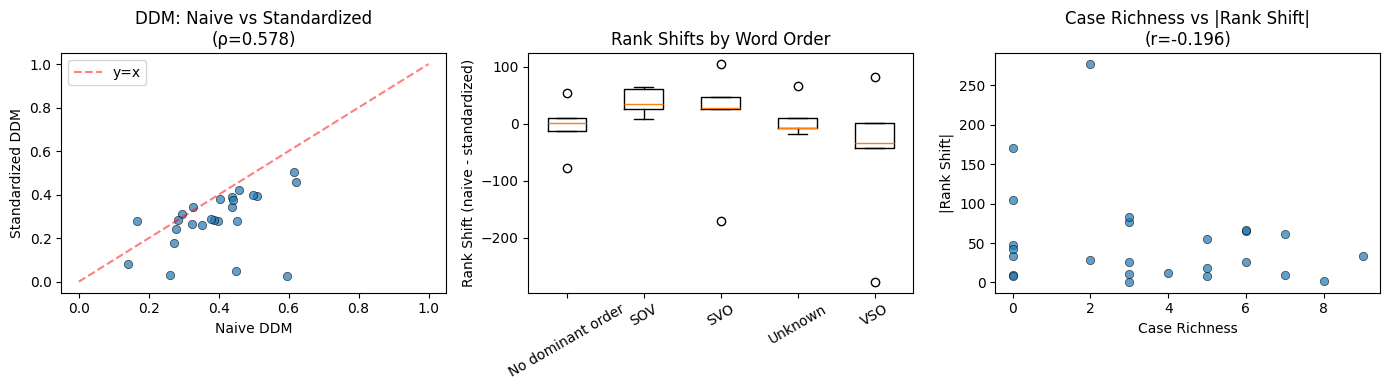

In [9]:
# === Summary Table ===
full_results = data["metadata"]["results"]
summary = full_results["summary"]
print("=" * 50)
print("HYPOTHESIS TEST RESULTS (full dataset, n=314)")
print("=" * 50)
for k, v in summary.items():
    status = "PASS ✓" if v else "FAIL ✗"
    print(f"  {k}: {status}")
print()
print(f"Demo replication (n={len(df_tb)}):")
print(f"  Spearman rho = {results_std['rho']:.4f} (pass rho<0.85: {results_std['pass_rho']})")
print(f"  Cohen's d    = {results_std['cohens_d']:.4f} (pass d>0.5: {results_std['pass_d']})")
print(f"  Linking corr = {results_linking['corr']:.4f} (p={results_linking['p']:.2e})")

# === Visualizations ===
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Naive vs Standardized DDM
ax = axes[0]
ax.scatter(df_tb["naive_ddm"], df_tb["standardized_ddm"], alpha=0.7, edgecolors="k", linewidth=0.5)
ax.plot([0, 1], [0, 1], "r--", alpha=0.5, label="y=x")
ax.set_xlabel("Naive DDM")
ax.set_ylabel("Standardized DDM")
ax.set_title(f"DDM: Naive vs Standardized\n(ρ={results_std['rho']:.3f})")
ax.legend()

# Plot 2: Rank shifts by word order
ax = axes[1]
df_plot = df_tb.copy()
df_plot["word_order_clean"] = df_plot["word_order"].fillna("Unknown")
wo_groups = df_plot.groupby("word_order_clean")["rank_shift"].apply(list)
ax.boxplot(wo_groups.values, labels=wo_groups.index, vert=True)
ax.set_ylabel("Rank Shift (naive - standardized)")
ax.set_title("Rank Shifts by Word Order")
ax.tick_params(axis="x", rotation=30)

# Plot 3: Case richness vs |rank shift|
ax = axes[2]
ax.scatter(df_tb["case_richness"], df_tb["rank_shift"].abs(), alpha=0.7, edgecolors="k", linewidth=0.5)
ax.set_xlabel("Case Richness")
ax.set_ylabel("|Rank Shift|")
ax.set_title(f"Case Richness vs |Rank Shift|\n(r={results_linking['corr']:.3f})")

plt.tight_layout()
plt.show()